In [35]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from scipy.io import wavfile

In [36]:
def to_float_audio(x):
    """
    Перевод сигнала из формата WAV в float64 в диапазон примерно [-1, 1].
    """
    if np.issubdtype(x.dtype, np.integer):
        info = np.iinfo(x.dtype)
        return x.astype(np.float64) / max(abs(info.min), info.max)
    return x.astype(np.float64)

In [37]:
def shift(x, fs, dt, at, f):
    """
    Получение смещённой версии сигнала с переменной задержкой.

    Parameters:
    x  : входной сигнал
    fs : частота дискретизации (Гц)
    dt : постоянная часть задержки (сек)
    at : амплитуда переменной части задержки (сек)
    f  : частота изменения переменной части (Гц)

    Returns:
    shifted : смещённый сигнал той же длины
    """
    x = np.asarray(x, dtype=np.float64)
    N = len(x)

    t_original = np.arange(N) / fs
    delay = dt + at * np.sin(2 * np.pi * f * t_original)
    t_source = t_original - delay

    if not np.all(np.diff(t_source) > 0):
        warnings.warn(
            "Внимание: t_source не является строго возрастающей. "
            "Результат может быть некорректным."
        )

    shifted = np.interp(t_source, t_original, x, left=0.0, right=0.0)
    return shifted

In [38]:
def generate_chorus(x, fs, chorus_params, dry_gain=0.6):
    """
    Наложение эффекта хоруса.

    Parameters:
    x             : входной сигнал
    fs            : частота дискретизации
    chorus_params : список словарей с параметрами копий
    dry_gain      : коэффициент оригинального сигнала

    Returns:
    output : сигнал с хорус-эффектом
    """
    x = to_float_audio(x)

    output = dry_gain * x.copy()

    for params in chorus_params:
        delayed = shift(x, fs, params['dt'], params['at'], params['f'])
        g = params.get('g', 1.0)
        output += g * delayed

    peak = np.max(np.abs(output))
    if peak > 1e-12:
        output = output / peak * 0.98

    return output

In [39]:
def visualize_delay_signals(chorus_params, fs, duration=2.0):
    """
    Рисует сигнал задержки для каждой копии в отдельном окне.
    """
    t = np.linspace(0, duration, int(duration * fs))

    for i, params in enumerate(chorus_params):
        delay = params['dt'] + params['at'] * np.sin(2 * np.pi * params['f'] * t)

        plt.figure(figsize=(10, 4))
        plt.plot(t, delay * 1000)
        plt.title(f'Сигнал задержки для копии {i + 1}')
        plt.xlabel('Время, с')
        plt.ylabel('Задержка, мс')
        plt.grid(True, alpha=0.3)
        plt.xlim(0, duration)
        plt.show()

In [40]:
def plot_original_and_chorus(x, y, fs, duration=0.05):
    """
    График исходного сигнала и сигнала после chorus.
    duration - сколько секунд показать в начале записи
    """
    x = to_float_audio(x)
    y = np.asarray(y, dtype=np.float64)

    N = min(len(x), len(y), int(duration * fs))
    t = np.arange(N) / fs

    plt.figure(figsize=(12, 5))
    plt.plot(t, x[:N], label='Исходный сигнал')
    plt.plot(t, y[:N], label='После chorus', alpha=0.8)
    plt.title('Сравнение исходного сигнала и сигнала после chorus')
    plt.xlabel('Время, с')
    plt.ylabel('Амплитуда')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [41]:
INPUT_WAV = "input.wav"

fs, x = wavfile.read(INPUT_WAV)
if x.ndim > 1:
    x = x[:, 0]

print(f"Частота дискретизации: {fs} Гц")
print(f"Число отсчётов: {len(x)}")
print(f"Длительность: {len(x) / fs:.2f} с")
print(f"Тип данных: {x.dtype}")

Частота дискретизации: 48000 Гц
Число отсчётов: 904320
Длительность: 18.84 с
Тип данных: int16


In [42]:
chorus_params = [
    {'dt': 0.020, 'at': 0.010, 'f': 3.0, 'g': 0.45},
    {'dt': 0.025, 'at': 0.008, 'f': 2.5, 'g': 0.40},
    {'dt': 0.015, 'at': 0.012, 'f': 4.0, 'g': 0.35},
    {'dt': 0.030, 'at': 0.015, 'f': 1.5, 'g': 0.30},
]

for i, p in enumerate(chorus_params):
    print(
        f"Копия {i+1}: "
        f"dt = {p['dt']*1000:.1f} мс, "
        f"at = {p['at']*1000:.1f} мс, "
        f"f = {p['f']:.2f} Гц, "
        f"g = {p['g']:.2f}"
    )

Копия 1: dt = 20.0 мс, at = 10.0 мс, f = 3.00 Гц, g = 0.45
Копия 2: dt = 25.0 мс, at = 8.0 мс, f = 2.50 Гц, g = 0.40
Копия 3: dt = 15.0 мс, at = 12.0 мс, f = 4.00 Гц, g = 0.35
Копия 4: dt = 30.0 мс, at = 15.0 мс, f = 1.50 Гц, g = 0.30


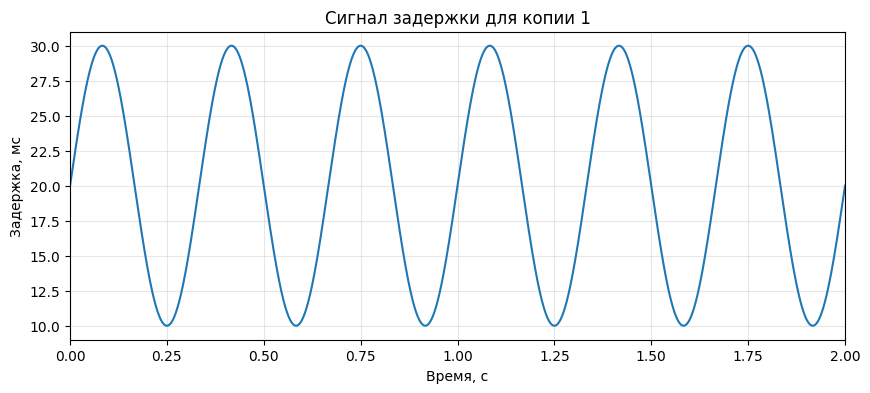

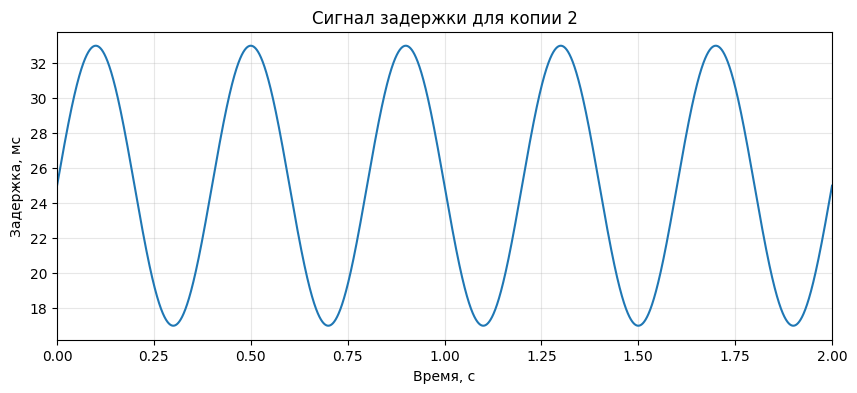

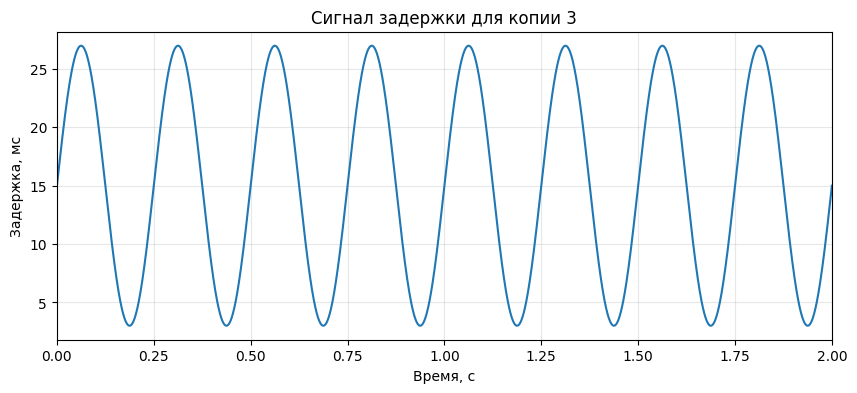

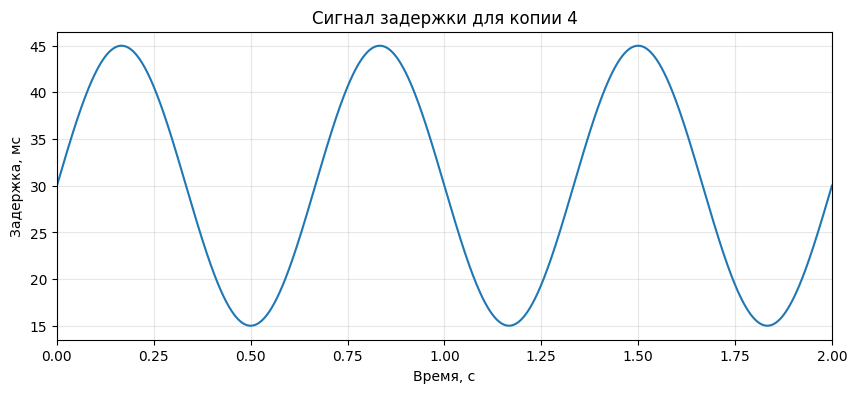

In [43]:
visualize_delay_signals(chorus_params, fs, duration=2.0)

In [44]:
y = generate_chorus(x, fs, chorus_params, dry_gain=0.45)
print("Хорус-эффект применён.")

Хорус-эффект применён.


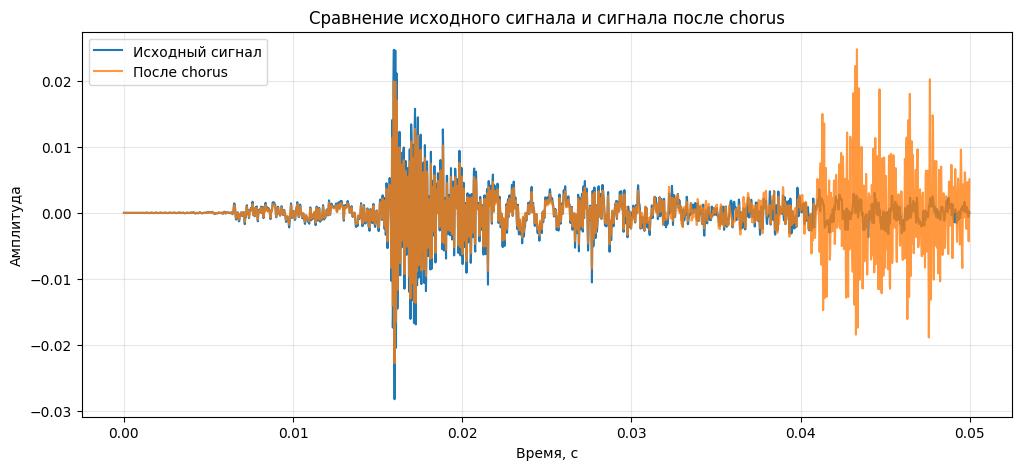

In [45]:
plot_original_and_chorus(x, y, fs, duration=0.05)

In [46]:
output_int16 = np.int16(np.clip(y, -1.0, 1.0) * 32767)

OUTPUT_WAV = "output_chorus.wav"
wavfile.write(OUTPUT_WAV, fs, output_int16)

print(f"Файл сохранён: {OUTPUT_WAV}")

Файл сохранён: output_chorus.wav
